In [1]:
import os
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"font.size": 10})
from sklearn.metrics import roc_auc_score, average_precision_score
import torch

In [2]:
import sys
sys.path.append("../src/")

%load_ext autoreload
%autoreload 2
# Importing our custom module(s)
import datasets
import layers
import losses
import models
import utils

In [3]:
default_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
for i, color in enumerate(default_colors):
    print(f"{i}: {color}")

0: #1f77b4
1: #ff7f0e
2: #2ca02c
3: #d62728
4: #9467bd
5: #8c564b
6: #e377c2
7: #7f7f7f
8: #bcbd22
9: #17becf


In [3]:
################################################################################
def print_job(
    alpha, criterion, data_seed_test, data_seed_train, data_seed_val, delta, r, 
    epochs, embedding_level, experiments_dir, lr, n_test, n_train, n_val, 
    pooling, save, seed, weight_decay
):
    model_name = f"alpha={alpha}_criterion={criterion}_lr={lr}_pooling={pooling}_seed={seed}"
    
    if os.path.exists(f"{experiments_dir}/{model_name}.csv"):
        temp_df = pd.read_csv(f"{experiments_dir}/{model_name}.csv")
        if temp_df.shape[0] == epochs:
            return
        
    embedding_level = "--embedding_level " if embedding_level else ""
    save = "--save " if save else ""
    
    command = (
        f"python ../src/synthetic_data.py "
        f"--alpha={alpha} "
        f"--batch_size={batch_size} "
        f"--criterion=\"{criterion}\" "
        f"--data_seed_test={data_seed_test} "
        f"--data_seed_train={data_seed_train} "
        f"--data_seed_val={data_seed_val} "
        f"--delta={delta} "
        f"--r={r} "
        f"--epochs={epochs} "
        f"{embedding_level}"
        f"--experiments_dir=\"{experiments_dir}\" "
        f"--lr={lr} "
        f"--model_name=\"{model_name}\" "
        f"--n_test={n_test} "
        f"--n_train={n_train} "
        f"--n_val={n_val} "
        f"--pooling=\"{pooling}\" "
        f"{save}"
        f"--seed={seed} "
        f"--weight_decay={weight_decay}"
    )
    
    print(f"    \'{command}\'")
    

In [5]:
alphas = [1.0, 0.1, 0.01, 0.001, 0.0001, 1e-05, 1e-06, 0.0]
batch_size = 64
criterions = ["L1"]
data_seed_test, data_seed_train, data_seed_val = 1003, 1001, 1002
data_seed_test, data_seed_train, data_seed_val = 2003, 2001, 2002
data_seed_test, data_seed_train, data_seed_val = 3003, 3001, 3002
delta = 0.5
epochs = 1000
#embedding_level = False
embedding_level = True
#experiments_dir = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/varying_n_embedding_level=False" 
experiments_dir = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/varying_n_embedding_level=True" 
lrs = [0.1, 0.01, 0.001, 0.0001]
n_trains = [100, 158, 251, 398, 630, 1000, 1584, 2511, 3981, 6309, 10000]
n_test = 1000
n_vals = [25, 39, 62, 99, 157, 250, 396, 627, 995, 1577, 2500]
#poolings = ["Max", "Mean", "ABMIL", "SmAP"]
poolings = ["Max", "Mean", "ABMIL", "TransMIL", "SmAP"]
r = 12
save = True
seeds = [1001]
seeds = [2001]
seeds = [3001]
weight_decay = 0.0

for alpha, criterion, lr, (n_train, n_val), pooling, seed in itertools.product(alphas, criterions, lrs, zip(n_trains, n_vals), poolings, seeds):

    dataset_folder = f"delta={delta}_r={r}_s_low=20_s_high=60"
    datasplit_folder = f"data_seed_test={data_seed_test}_data_seed_train={data_seed_train}_data_seed_val={data_seed_val}_n_test={n_test}_n_train={n_train}_n_val={n_val}"
    temp_experiments_dir = f"{experiments_dir}/{dataset_folder}/{datasplit_folder}" 
    model_name = f"alpha={alpha}_criterion={criterion}_lr={lr}_pooling={pooling}_seed={seed}"

    print_job(alpha, criterion, data_seed_test, data_seed_train, data_seed_val, 
              delta, r, epochs, embedding_level, temp_experiments_dir, lr, 
              n_test, n_train, n_val, pooling, save, seed, weight_decay)

In [6]:
alphas = [1.0, 0.1, 0.01, 0.001, 0.0001, 1e-05, 1e-06, 0.0]
batch_size = 64
criterions = ["L1"]
data_seed_test, data_seed_train, data_seed_val = 1003, 1001, 1002
#data_seed_test, data_seed_train, data_seed_val = 2003, 2001, 2002
#data_seed_test, data_seed_train, data_seed_val = 3003, 3001, 3002
delta = 0.5
epochs = 1000
#embedding_level = False
embedding_level = True
#experiments_dir = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/varying_n_embedding_level=False" 
experiments_dir = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/varying_n_embedding_level=True" 
lrs = [0.1, 0.01, 0.001, 0.0001]
n_trains = [100, 158, 251, 398, 630, 1000, 1584, 2511, 3981, 6309, 10000]
n_trains = [10000]
n_test = 1000
n_vals = [25, 39, 62, 99, 157, 250, 396, 627, 995, 1577, 2500]
n_vals = [2500]
#poolings = ["Max", "Mean", "ABMIL", "TransMIL", "SmAP"]
poolings = ["ABMIL"]
r = 12
save = True
seeds = [1001]
#seeds = [2001]
#seeds = [3001]
weight_decay = 0.0

columns = ["model_name", "n_train", "seed", "test_auroc", "test_auprc", "test_bal_acc", "test_loss", "test_nll", "train_auroc", "train_auprc", "train_bal_acc", "train_loss", "train_nll", "val_auroc", "val_auprc", "val_bal_acc", "val_loss", "val_nll"]
df = pd.DataFrame(columns=columns)

for alpha, criterion, lr, (n_train, n_val), pooling, seed in itertools.product(alphas, criterions, lrs, zip(n_trains, n_vals), poolings, seeds):

    dataset_folder = f"delta={delta}_r={r}_s_low=20_s_high=60"
    datasplit_folder = f"data_seed_test={data_seed_test}_data_seed_train={data_seed_train}_data_seed_val={data_seed_val}_n_test={n_test}_n_train={n_train}_n_val={n_val}"
    temp_experiments_dir = f"{experiments_dir}/{dataset_folder}/{datasplit_folder}"
    model_name = f"alpha={alpha}_criterion={criterion}_lr={lr}_pooling={pooling}_seed={seed}"

    if os.path.exists(f"{temp_experiments_dir}/{model_name}.csv"):
        temp_df = pd.read_csv(f"{temp_experiments_dir}/{model_name}.csv")
        if len(temp_df[temp_df.train_auroc>temp_df.val_auroc]):
            index = temp_df[temp_df.train_auroc>temp_df.val_auroc].val_auroc.idxmax()
            row = [model_name, n_train, seed, temp_df.test_auroc.values[index], temp_df.test_auprc.values[index], temp_df.test_bal_acc.values[index], temp_df.test_loss.values[index], temp_df.test_nll.values[index], temp_df.train_auroc.values[index], temp_df.train_auprc.values[index], temp_df.train_bal_acc.values[index], temp_df.train_loss.values[index], temp_df.train_nll.values[index], temp_df.val_auroc.values[index], temp_df.val_auprc.values[index], temp_df.val_bal_acc.values[index], temp_df.val_loss.values[index], temp_df.val_nll.values[index]]
            df.loc[len(df)] = row
        
indices = df.groupby(["n_train", "seed"])["val_auroc"].idxmax()
df = df.loc[indices].reset_index(drop=True)
df

,model_name,n_train,seed,test_auroc,test_auprc,test_bal_acc,test_loss,test_nll,train_auroc,train_auprc,train_bal_acc,train_loss,train_nll,val_auroc,val_auprc,val_bal_acc,val_loss,val_nll
0,alpha=0.01_criterion=L1_lr=0.1_pooling=ABMIL_s...,10000,1001,0.754044,0.766023,0.680643,0.796016,0.588642,0.757949,0.760167,0.686203,0.792242,0.584548,0.75462,0.725571,0.694492,0.800514,0.59314


In [7]:
df.test_auroc.values

array([0.75404379])

In [8]:
df.model_name.values

array(['alpha=0.01_criterion=L1_lr=0.1_pooling=ABMIL_seed=1001'],
      dtype=object)

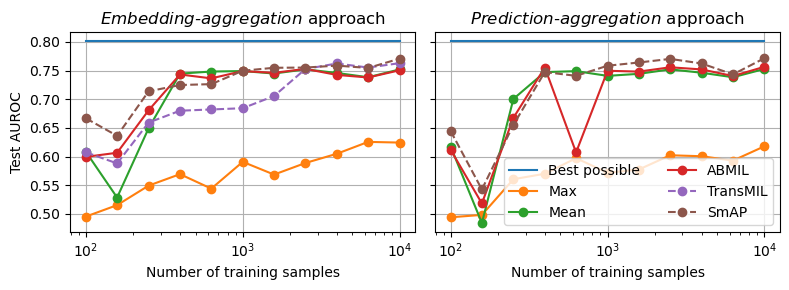

In [9]:
n_trains = [100, 158, 251, 398, 630, 1000, 1584, 2511, 3981, 6309, 10000]

bayes_auroc_means = [0.8008569679657214, 0.8008569679657214, 0.8008569679657214, 0.8008569679657214, 0.8008569679657214, 0.8008569679657214, 0.8008569679657214, 0.8008569679657214, 0.8008569679657214, 0.8008569679657214, 0.8008569679657214]

embed_max_aurocs1 = [0.50314662, 0.50986393, 0.5387816, 0.63234594, 0.51443283, 0.56015579, 0.56764726, 0.60779513, 0.61899732, 0.63384023, 0.63261199]
embed_mean_aurocs1 = [0.72167945, 0.51212638, 0.52340659, 0.75115523, 0.74050114, 0.75377174, 0.75171934, 0.75235146, 0.75073914, 0.73465199, 0.75034307]
embed_abmil_aurocs1 = [0.74771055, 0.57994967, 0.55551288, 0.74071918, 0.69850491, 0.74675836, 0.75043108, 0.74989098, 0.75400779, 0.74095723, 0.75404379]
embed_transmil_aurocs1 = [0.60668491, 0.58281223, 0.54776136, 0.64751091, 0.67333997, 0.68763878, 0.65123964, 0.7342039, 0.74792259, 0.75298358, 0.75060712]
embed_smap_aurocs1 = [0.7066105, 0.63344816, 0.69939308, 0.73188745, 0.7076387, 0.74164136, 0.75200739, 0.75946085, 0.76809255, 0.75743246, 0.77739237]

embed_max_aurocs2 = [0.48523387, 0.5312805, 0.52006289, 0.56889792, 0.54647469, 0.59401154, 0.59501768, 0.60499512, 0.61227617, 0.62679826, 0.62560609]
embed_mean_aurocs2 = [0.5645653, 0.52190915, 0.72349018, 0.73607199, 0.75015802, 0.74632747, 0.72633259, 0.74834376, 0.7472036, 0.72731673, 0.75158023]
embed_abmil_aurocs2 = [0.54865701, 0.69878663, 0.72965907, 0.74368909, 0.75147621, 0.74691156, 0.73133331, 0.75037205, 0.743073, 0.71879351, 0.74975997]
embed_transmil_aurocs2 = [0.55502392, 0.56362916, 0.69336784, 0.69736442, 0.66157727, 0.71357275, 0.70666976, 0.78569714, 0.79299419, 0.75397657, 0.78068842]
embed_smap_aurocs2 = [0.71338873, 0.72249404, 0.72963907, 0.72982109, 0.76274984, 0.74953193, 0.75401658, 0.74907187, 0.75510874, 0.75021203, 0.77326735]

embed_max_aurocs3 = [0.49810251, 0.50498791, 0.58937607, 0.50695345, 0.57145602, 0.61845487, 0.54328393, 0.55383421, 0.5835495, 0.61638324, 0.61516229]
embed_mean_aurocs3 = [0.53820996, 0.55188868, 0.70148396, 0.74678948, 0.75428736, 0.74742198, 0.75654113, 0.75575651, 0.73963387, 0.75317849, 0.75398913]
embed_abmil_aurocs3 = [0.5024259, 0.5413204, 0.75718363, 0.74529031, 0.75927327, 0.75377096, 0.75637099, 0.75861075, 0.73031257, 0.75419529, 0.7476982]
embed_transmil_aurocs3 = [0.66065195, 0.61797449, 0.7369858, 0.69519703, 0.71167395, 0.65195914, 0.75899105, 0.73834286, 0.746173, 0.75883092, 0.7575259]
embed_smap_aurocs3 = [0.58016285, 0.55274735, 0.71254664, 0.71280284, 0.70865158, 0.75797825, 0.75863477, 0.75723767, 0.75283022, 0.75608877, 0.76164513]

pred_max_aurocs1 = [0.49819365, 0.50325864, 0.52693328, 0.60451448, 0.63618869, 0.5652908, 0.56003377, 0.64318206, 0.64969734, 0.62015755, 0.64545651]
pred_mean_aurocs1 = [0.75345768, 0.48375882, 0.67707671, 0.74751451, 0.74116527, 0.75377174, 0.75012302, 0.75234946, 0.75134326, 0.73464399, 0.75237547]
pred_abmil_aurocs1 = [0.73241555, 0.54226428, 0.5443867, 0.75318362, 0.49611724, 0.75370773, 0.75955287, 0.76126121, 0.76183732, 0.74302163, 0.76012098]
pred_smap_aurocs1 = [0.74124928, 0.55352049, 0.515319, 0.7505311, 0.71848482, 0.76663826, 0.76852263, 0.77451581, 0.77577605, 0.75720041, 0.77773644]

pred_max_aurocs2 = [0.49142276, 0.47961306, 0.58190579, 0.61933718, 0.58022555, 0.5381655, 0.55151942, 0.55980861, 0.5791554, 0.59118913, 0.59450161]
pred_mean_aurocs2 = [0.55951057, 0.47620257, 0.72348818, 0.73607199, 0.75230433, 0.7465115, 0.72633459, 0.74834776, 0.74775968, 0.72731673, 0.75196428]
pred_abmil_aurocs2 = [0.53951969, 0.53359684, 0.74230889, 0.75252636, 0.56788978, 0.74555136, 0.72840089, 0.74746564, 0.75323647, 0.72595654, 0.75461266]
pred_smap_aurocs2 = [0.57467075, 0.54887904, 0.7409727, 0.73644805, 0.75271439, 0.75262438, 0.7590133, 0.76635436, 0.77192316, 0.7242803, 0.77410747]

pred_max_aurocs3 = [0.49303454, 0.51216554, 0.57292517, 0.48651943, 0.57530504, 0.61231806, 0.6209188, 0.60397552, 0.57306528, 0.56770908, 0.61375118]
pred_mean_aurocs3 = [0.53820996, 0.49250012, 0.70117772, 0.75830251, 0.75363685, 0.72209212, 0.75654113, 0.75575651, 0.73962987, 0.75317449, 0.75399513]
pred_abmil_aurocs3 = [0.56263511, 0.4790776, 0.7161935, 0.76024203, 0.75782814, 0.7497478, 0.75672527, 0.75845863, 0.74092889, 0.752548, 0.75493587]
pred_smap_aurocs3 = [0.61674153, 0.52569815, 0.70993859, 0.75518807, 0.75137508, 0.75610479, 0.76477158, 0.77020384, 0.7394137, 0.74853885, 0.76266993]

ncols, nrows = 2, 1
fig, axs = plt.subplots(figsize=(4*ncols, 3*nrows), ncols=ncols, nrows=nrows, sharey=True)

axs[0].plot(n_trains, bayes_auroc_means, color="#1F77B4", label="Best possible")
axs[0].plot(n_trains, np.nanmean(np.stack([embed_max_aurocs1, embed_max_aurocs2, embed_max_aurocs3]), axis=0), color="#FF7F0E", label="Max", marker="o")
axs[0].plot(n_trains, np.nanmean(np.stack([embed_mean_aurocs1, embed_mean_aurocs2, embed_mean_aurocs3]), axis=0), color="#2CA02C", label="Mean", marker="o")
axs[0].plot(n_trains, np.nanmean(np.stack([embed_abmil_aurocs1, embed_abmil_aurocs2, embed_abmil_aurocs3]), axis=0), color="#D62728", label="ABMIL", marker="o")
axs[0].plot(n_trains, np.nanmean(np.stack([embed_transmil_aurocs1, embed_transmil_aurocs2, embed_transmil_aurocs3]), axis=0), color="#9467BD", label="TransMIL", linestyle="--", marker="o")
axs[0].plot(n_trains, np.nanmean(np.stack([embed_smap_aurocs1, embed_smap_aurocs2, embed_smap_aurocs3]), axis=0), color="#8C564B", label="SmAP", linestyle="--", marker="o")

axs[0].set_title(r"$\it{Embedding}$-$\it{aggregation}$ approach")
axs[0].set_xlabel("Number of training samples")
axs[0].set_ylabel("Test AUROC")
axs[0].set_xscale("log")
axs[0].grid()

axs[1].plot(n_trains, bayes_auroc_means, color="#1F77B4", label="Best possible")
axs[1].plot(n_trains, np.nanmean(np.stack([pred_max_aurocs1, pred_max_aurocs2, pred_max_aurocs3]), axis=0), color="#FF7F0E", label="Max", marker="o")
axs[1].plot(n_trains, np.nanmean(np.stack([pred_mean_aurocs1, pred_mean_aurocs2, pred_mean_aurocs3]), axis=0), color="#2CA02C", label="Mean", marker="o")
axs[1].plot(n_trains, np.nanmean(np.stack([pred_abmil_aurocs1, pred_abmil_aurocs2, pred_abmil_aurocs3]), axis=0), color="#D62728", label="ABMIL", marker="o")
axs[1].plot([], [], color="#9467BD", label="TransMIL", linestyle="--", marker="o")
axs[1].plot(n_trains, np.nanmean(np.stack([pred_smap_aurocs1, pred_smap_aurocs2, pred_smap_aurocs3]), axis=0), color="#8C564B", label="SmAP", linestyle="--", marker="o")

axs[1].set_title(r"$\it{Prediction}$-$\it{aggregation}$ approach")
axs[1].set_xlabel("Number of training samples")
axs[1].set_xscale("log")
axs[1].legend(loc="lower right", ncol=2)
axs[1].grid()

fig.tight_layout()
fig.savefig("shifted_mean_mil_varying_number_of_training_samples.pdf", bbox_inches="tight")
plt.show()


In [4]:
alphas = [1.0, 0.1, 0.01, 0.001, 0.0001, 1e-05, 1e-06, 0.0]
alphas = [0.001]
batch_size = 64
criterions = ["GuidedL1"]
data_seeds_test = [1003, 2003, 3003]
data_seeds_train = [1001, 2001, 3001]
data_seeds_val = [1002, 2002, 3002]
delta = 0.5
epochs = 1000
embedding_level = True
experiments_dir = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/varying_n_embedding_level=True" 
#experiments_dir = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/varying_n_beta=1.0_embedding_level=True" 
experiments_dir = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/varying_n_beta2=1.0_embedding_level=True" 
#experiments_dir = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/varying_n_beta=1.0_embedding_level=True_multi_head=False" 
lrs = [0.1, 0.01, 0.001, 0.0001]
n_train = 10000
n_test = 1000
n_val = 2500
#poolings = ["Max", "Mean", "ABMIL", "TransMIL", "SmAP"]
poolings = ["TransMIL"]
r = 12
save = True
seeds = [1001, 2001, 3001]
weight_decay = 0.0

columns = ["model_name", "n_train", "seed", "test_auroc", "test_auprc", "test_bal_acc", "test_loss", "test_nll", "train_auroc", "train_auprc", "train_bal_acc", "train_loss", "train_nll", "val_auroc", "val_auprc", "val_bal_acc", "val_loss", "val_nll"]
df = pd.DataFrame(columns=columns)

for alpha, criterion, lr, (data_seed_test, data_seed_train, data_seed_val, seed), pooling in itertools.product(alphas, criterions, lrs, zip(data_seeds_test, data_seeds_train, data_seeds_val, seeds), poolings):

    dataset_folder = f"delta={delta}_r={r}_s_low=20_s_high=60"
    datasplit_folder = f"data_seed_test={data_seed_test}_data_seed_train={data_seed_train}_data_seed_val={data_seed_val}_n_test={n_test}_n_train={n_train}_n_val={n_val}"
    temp_experiments_dir = f"{experiments_dir}/{dataset_folder}/{datasplit_folder}" 
    model_name = f"alpha={alpha}_criterion={criterion}_lr={lr}_pooling={pooling}_seed={seed}"

    print_job(alpha, criterion, data_seed_test, data_seed_train, data_seed_val, 
              delta, r, epochs, embedding_level, temp_experiments_dir, lr, 
              n_test, n_train, n_val, pooling, save, seed, weight_decay)

In [5]:
alphas = [1.0, 0.1, 0.01, 0.001, 0.0001, 1e-05, 1e-06, 0.0]
batch_size = 64
criterions = ["GuidedL1"]
data_seeds_test = [1003, 2003, 3003]
data_seeds_train = [1001, 2001, 3001]
data_seeds_val = [1002, 2002, 3002]
delta = 0.5
epochs = 1000
embedding_level = True
experiments_dir = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/varying_n_embedding_level=True" 
#experiments_dir = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/varying_n_beta=1.0_embedding_level=True" 
experiments_dir = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/varying_n_beta2=1.0_embedding_level=True" 
experiments_dir = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/varying_n_beta=1.0_embedding_level=True_multi_head=False" 
lrs = [0.1, 0.01, 0.001, 0.0001]
n_train = 10000
n_test = 1000
n_val = 2500
#poolings = ["Max", "Mean", "ABMIL", "TransMIL", "SmAP"]
poolings = ["TransMIL"]
r = 12
save = True
seeds = [1001, 2001, 3001]
weight_decay = 0.0

columns = ["model_name", "n_train", "seed", "test_auroc", "test_auprc", "test_bal_acc", "test_loss", "test_nll", "train_auroc", "train_auprc", "train_bal_acc", "train_loss", "train_nll", "val_auroc", "val_auprc", "val_bal_acc", "val_loss", "val_nll"]
df = pd.DataFrame(columns=columns)

for alpha, criterion, lr, (data_seed_test, data_seed_train, data_seed_val, seed), pooling in itertools.product(alphas, criterions, lrs, zip(data_seeds_test, data_seeds_train, data_seeds_val, seeds), poolings):

    dataset_folder = f"delta={delta}_r={r}_s_low=20_s_high=60"
    datasplit_folder = f"data_seed_test={data_seed_test}_data_seed_train={data_seed_train}_data_seed_val={data_seed_val}_n_test={n_test}_n_train={n_train}_n_val={n_val}"
    temp_experiments_dir = f"{experiments_dir}/{dataset_folder}/{datasplit_folder}"
    model_name = f"alpha={alpha}_criterion={criterion}_lr={lr}_pooling={pooling}_seed={seed}"

    if os.path.exists(f"{temp_experiments_dir}/{model_name}.csv"):
        temp_df = pd.read_csv(f"{temp_experiments_dir}/{model_name}.csv")
        if len(temp_df[temp_df.train_auroc>temp_df.val_auroc]):
            index = temp_df[temp_df.train_auroc>temp_df.val_auroc].val_auroc.idxmax()
            row = [model_name, n_train, seed, temp_df.test_auroc.values[index], temp_df.test_auprc.values[index], temp_df.test_bal_acc.values[index], temp_df.test_loss.values[index], temp_df.test_nll.values[index], temp_df.train_auroc.values[index], temp_df.train_auprc.values[index], temp_df.train_bal_acc.values[index], temp_df.train_loss.values[index], temp_df.train_nll.values[index], temp_df.val_auroc.values[index], temp_df.val_auprc.values[index], temp_df.val_bal_acc.values[index], temp_df.val_loss.values[index], temp_df.val_nll.values[index]]
            df.loc[len(df)] = row
        
indices = df.groupby(["n_train", "seed"])["val_auroc"].idxmax()
df = df.loc[indices].reset_index(drop=True)
df

,model_name,n_train,seed,test_auroc,test_auprc,test_bal_acc,test_loss,test_nll,train_auroc,train_auprc,train_bal_acc,train_loss,train_nll,val_auroc,val_auprc,val_bal_acc,val_loss,val_nll
0,alpha=0.001_criterion=GuidedL1_lr=0.0001_pooli...,10000,1001,0.750491,0.762456,0.675600,3.501828,0.592037,0.760296,0.761868,0.690696,3.499238,0.584901,0.751267,0.721521,0.689756,3.506851,0.597122
1,alpha=0.001_criterion=GuidedL1_lr=0.001_poolin...,10000,2001,0.785453,0.791008,0.693376,2.998888,0.557697,0.807217,0.811684,0.728869,2.975752,0.532014,0.783420,0.778847,0.711790,3.004962,0.564479
2,alpha=0.001_criterion=GuidedL1_lr=0.001_poolin...,10000,3001,0.769215,0.772626,0.692359,2.645626,0.574170,0.801938,0.801391,0.726166,2.612091,0.539349,0.769174,0.763131,0.694954,2.652071,0.580673


In [6]:
print(f"${df.test_auroc.mean():.3f}${{\\tiny$\pm {df.test_auroc.std():.3f}$}}")
print(f"${df.test_auprc.mean():.3f}${{\\tiny$\pm {df.test_auprc.std():.3f}$}}")


$0.768${\tiny$\pm 0.017$}
$0.775${\tiny$\pm 0.014$}


In [8]:
df.model_name.values

array(['alpha=0.001_criterion=GuidedL1_lr=0.0001_pooling=TransMIL_seed=1001',
       'alpha=0.001_criterion=GuidedL1_lr=0.001_pooling=TransMIL_seed=2001',
       'alpha=0.001_criterion=GuidedL1_lr=0.001_pooling=TransMIL_seed=3001'],
      dtype=object)

In [20]:
test_dataset = datasets.ShiftedMeanMILDataset(n=1_000, r=12, s_low=20, s_high=60, delta=0.5, seed=1_003)

def normal_pdf(x, mu=0.0, sigma=1.0):
    norm_const = 1 / np.sqrt(2.0 * np.pi * sigma**2)
    exp_quad_term = np.exp(-0.5 * ((x - mu) / sigma) ** 2)
    return norm_const * exp_quad_term

model = models.PoolClf(in_features=768, out_features=1, pooling="ABMIL")
model = models.PoolClf(in_features=768, out_features=1, pooling="TransMIL")
#model = models.PoolClf(in_features=768, out_features=1, pooling="SmAP")
#model = models.PoolClf(in_features=768, out_features=1, pooling="SmTAP")

#checkpoint_path = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/varying_n_embedding_level=True/delta=0.5_r=12_s_low=20_s_high=60/data_seed_test=1003_data_seed_train=1001_data_seed_val=1002_n_test=1000_n_train=10000_n_val=2500/alpha=0.01_criterion=L1_lr=0.1_pooling=ABMIL_seed=1001.pt"
#checkpoint_path = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/varying_n_embedding_level=True/delta=0.5_r=12_s_low=20_s_high=60/data_seed_test=2003_data_seed_train=2001_data_seed_val=2002_n_test=1000_n_train=10000_n_val=2500/alpha=0.01_criterion=L1_lr=0.1_pooling=ABMIL_seed=2001.pt"
#checkpoint_path = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/varying_n_embedding_level=True/delta=0.5_r=12_s_low=20_s_high=60/data_seed_test=3003_data_seed_train=3001_data_seed_val=3002_n_test=1000_n_train=10000_n_val=2500/alpha=0.001_criterion=L1_lr=0.001_pooling=ABMIL_seed=3001.pt"
#checkpoint_path = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/varying_n_embedding_level=True/delta=0.5_r=12_s_low=20_s_high=60/data_seed_test=1003_data_seed_train=1001_data_seed_val=1002_n_test=1000_n_train=10000_n_val=2500/alpha=0.001_criterion=L1_lr=0.0001_pooling=TransMIL_seed=1001.pt"
#checkpoint_path = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/varying_n_embedding_level=True/delta=0.5_r=12_s_low=20_s_high=60/data_seed_test=2003_data_seed_train=2001_data_seed_val=2002_n_test=1000_n_train=10000_n_val=2500/alpha=0.001_criterion=L1_lr=0.001_pooling=TransMIL_seed=2001.pt"
#checkpoint_path = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/varying_n_embedding_level=True/delta=0.5_r=12_s_low=20_s_high=60/data_seed_test=3003_data_seed_train=3001_data_seed_val=3002_n_test=1000_n_train=10000_n_val=2500/alpha=0.001_criterion=L1_lr=0.0001_pooling=TransMIL_seed=3001.pt"
#checkpoint_path = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/varying_n_embedding_level=True/delta=0.5_r=12_s_low=20_s_high=60/data_seed_test=1003_data_seed_train=1001_data_seed_val=1002_n_test=1000_n_train=10000_n_val=2500/alpha=0.01_criterion=L1_lr=0.01_pooling=SmAP_seed=1001.pt"
#checkpoint_path = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/varying_n_embedding_level=True/delta=0.5_r=12_s_low=20_s_high=60/data_seed_test=2003_data_seed_train=2001_data_seed_val=2002_n_test=1000_n_train=10000_n_val=2500/alpha=0.01_criterion=L1_lr=0.01_pooling=SmAP_seed=2001.pt"
#checkpoint_path = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/varying_n_embedding_level=True/delta=0.5_r=12_s_low=20_s_high=60/data_seed_test=3003_data_seed_train=3001_data_seed_val=3002_n_test=1000_n_train=10000_n_val=2500/alpha=0.01_criterion=L1_lr=0.001_pooling=SmAP_seed=3001.pt"
#checkpoint_path = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/varying_n_embedding_level=True/delta=0.5_r=12_s_low=20_s_high=60/data_seed_test=1003_data_seed_train=1001_data_seed_val=1002_n_test=1000_n_train=10000_n_val=2500/alpha=0.001_criterion=L1_lr=0.01_pooling=SmTAP_seed=1001.pt"
#checkpoint_path = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/varying_n_embedding_level=True/delta=0.5_r=12_s_low=20_s_high=60/data_seed_test=2003_data_seed_train=2001_data_seed_val=2002_n_test=1000_n_train=10000_n_val=2500/alpha=0.001_criterion=L1_lr=0.01_pooling=SmTAP_seed=2001.pt"
#checkpoint_path = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/varying_n_embedding_level=True/delta=0.5_r=12_s_low=20_s_high=60/data_seed_test=3003_data_seed_train=3001_data_seed_val=3002_n_test=1000_n_train=10000_n_val=2500/alpha=0.001_criterion=L1_lr=0.0001_pooling=SmTAP_seed=3001.pt"

#checkpoint_path = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/varying_n_beta=1.0_embedding_level=True/delta=0.5_r=12_s_low=20_s_high=60/data_seed_test=1003_data_seed_train=1001_data_seed_val=1002_n_test=1000_n_train=10000_n_val=2500/alpha=0.01_criterion=GuidedL1_lr=0.1_pooling=ABMIL_seed=1001.pt"
#checkpoint_path = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/varying_n_beta=1.0_embedding_level=True/delta=0.5_r=12_s_low=20_s_high=60/data_seed_test=2003_data_seed_train=2001_data_seed_val=2002_n_test=1000_n_train=10000_n_val=2500/alpha=0.1_criterion=GuidedL1_lr=0.0001_pooling=ABMIL_seed=2001.pt"
#checkpoint_path = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/varying_n_beta=1.0_embedding_level=True/delta=0.5_r=12_s_low=20_s_high=60/data_seed_test=3003_data_seed_train=3001_data_seed_val=3002_n_test=1000_n_train=10000_n_val=2500/alpha=0.001_criterion=GuidedL1_lr=0.01_pooling=ABMIL_seed=3001.pt"
#checkpoint_path = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/varying_n_beta=1.0_embedding_level=True/delta=0.5_r=12_s_low=20_s_high=60/data_seed_test=1003_data_seed_train=1001_data_seed_val=1002_n_test=1000_n_train=10000_n_val=2500/alpha=0.001_criterion=GuidedL1_lr=0.1_pooling=TransMIL_seed=1001.pt"
#checkpoint_path = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/varying_n_beta=1.0_embedding_level=True/delta=0.5_r=12_s_low=20_s_high=60/data_seed_test=2003_data_seed_train=2001_data_seed_val=2002_n_test=1000_n_train=10000_n_val=2500/alpha=0.001_criterion=GuidedL1_lr=0.001_pooling=TransMIL_seed=2001.pt"
#checkpoint_path = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/varying_n_beta=1.0_embedding_level=True/delta=0.5_r=12_s_low=20_s_high=60/data_seed_test=3003_data_seed_train=3001_data_seed_val=3002_n_test=1000_n_train=10000_n_val=2500/alpha=0.001_criterion=GuidedL1_lr=0.0001_pooling=TransMIL_seed=3001.pt"

checkpoint_path = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/varying_n_beta2=1.0_embedding_level=True/delta=0.5_r=12_s_low=20_s_high=60/data_seed_test=1003_data_seed_train=1001_data_seed_val=1002_n_test=1000_n_train=10000_n_val=2500/alpha=0.001_criterion=GuidedL1_lr=0.0001_pooling=TransMIL_seed=1001.pt"
#checkpoint_path = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/varying_n_beta2=1.0_embedding_level=True/delta=0.5_r=12_s_low=20_s_high=60/data_seed_test=2003_data_seed_train=2001_data_seed_val=2002_n_test=1000_n_train=10000_n_val=2500/alpha=0.001_criterion=GuidedL1_lr=0.001_pooling=TransMIL_seed=2001.pt"
#checkpoint_path = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/varying_n_beta2=1.0_embedding_level=True/delta=0.5_r=12_s_low=20_s_high=60/data_seed_test=3003_data_seed_train=3001_data_seed_val=3002_n_test=1000_n_train=10000_n_val=2500/alpha=0.001_criterion=GuidedL1_lr=0.001_pooling=TransMIL_seed=3001.pt"



checkpoint = torch.load(checkpoint_path, map_location=torch.device("cpu"))

model.load_state_dict(checkpoint)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)
model.to(device)

attn_corrs = []
aurocs = []
auprcs = []

with torch.no_grad():
    
    for i in range(len(test_dataset)):
        h_i, S_i, y_i = test_dataset[i]
        y_ij = np.zeros(test_dataset.lengths[i])
        y_ij[test_dataset.u[i]:test_dataset.u[i] + test_dataset.r] = 1.0

        if y_i == 1.0:
            #x = torch.arange(start=1, end=S_i + 1)
            #a_i = utils.normal_pdf(x, mu=S_i / 2, sigma=1.0)
            #a_i = a_i / a_i.sum()
            #a_i = torch.stack([torch.sum(torch.argmax(h_i, dim=0, keepdim=True) == j) / h_i.shape[1] for j in range(S_i)]).unsqueeze(1)
            #a_i = np.ones_like(y_ij) / S_i
            _, a_i = model(h_i, (S_i,))
            a_i = torch.mean(a_i, dim=1).detach()
            attn_corrs.append(a_i[np.array(y_ij) == 1.0].sum())
            aurocs.append(roc_auc_score(y_ij, a_i))
            auprcs.append(average_precision_score(y_ij, a_i))


cpu


In [21]:
print(np.mean(attn_corrs))
print(np.mean(aurocs))
print(np.mean(auprcs))

0.32018426
0.49593994103083583
0.3847442826228191


In [23]:
guided2_transmil_aurocs =[0.49593994103083583, 0.7813251514200836, 0.5471113804988887]
guided2_transmil_auprcs =[0.3847442826228191, 0.6899816003789863, 0.4255758171851518]
print(f"${np.mean(guided2_transmil_aurocs):.3f}${{\\tiny$\pm {np.std(guided2_transmil_aurocs):.3f}$}}")
print(f"${np.mean(guided2_transmil_auprcs):.3f}${{\\tiny$\pm {np.std(guided2_transmil_auprcs):.3f}$}}")


$0.608${\tiny$\pm 0.124$}
$0.500${\tiny$\pm 0.135$}


In [13]:
smtap_aurocs = [0.5018898409233544, 0.7710638314923091, 0.503008794499089]
smtap_auprcs = [0.33553491259560997, 0.6713118982127234, 0.3932026858621753]
print(f"${np.mean(smtap_aurocs):.3f}${{\\tiny$\pm {np.std(smtap_aurocs):.3f}$}}")
print(f"${np.mean(smtap_auprcs):.3f}${{\\tiny$\pm {np.std(smtap_auprcs):.3f}$}}")


$0.592${\tiny$\pm 0.127$}
$0.467${\tiny$\pm 0.147$}


In [25]:
guided_abmil_aurocs = [0.505078235971831, 0.5, 0.6182178060714955]
guided_abmil_auprcs = [0.3886691155316371, 0.3357159409301088, 0.48557383178637237]
print(f"${np.mean(guided_abmil_aurocs):.3f}${{\\tiny$\pm {np.std(guided_abmil_aurocs):.3f}$}}")
print(f"${np.mean(guided_abmil_auprcs):.3f}${{\\tiny$\pm {np.std(guided_abmil_auprcs):.3f}$}}")


$0.541${\tiny$\pm 0.055$}
$0.403${\tiny$\pm 0.062$}


In [14]:
guided_transmil_aurocs =[0.7085705719998039, 0.7973199690145041, 0.6111668214663684]
guided_transmil_auprcs =[0.5586911870532076, 0.6921756613038226, 0.4839027028939869]
print(f"${np.mean(guided_transmil_aurocs):.3f}${{\\tiny$\pm {np.std(guided_transmil_aurocs):.3f}$}}")
print(f"${np.mean(guided_transmil_auprcs):.3f}${{\\tiny$\pm {np.std(guided_transmil_auprcs):.3f}$}}")


$0.706${\tiny$\pm 0.076$}
$0.578${\tiny$\pm 0.086$}


In [129]:
gaussian_attn_corr = [0.5088610492197759, 0.46932601652709205, 0.5007064061009457]
max_attn_corr = [0.3276884, 0.33671466, 0.33253282]
mean_attn_corr = [0.32747554507733595, 0.3357159409301088, 0.33146503201600513]
abmil_attn_corr = [0.32747594, 0.3357163, 0.34379613]
transmil_attn_corr = [0.31792292, 0.3676405, 0.3217009]
smap_attn_corr = [0.39297292, 0.4132654, 0.39253622]
print(f"${np.mean(max_attn_corr):.3f}${{\\tiny$\pm {np.std(max_attn_corr):.3f}$}}")


$0.336${\tiny$\pm 0.007$}


In [10]:
gaussian_aurocs = [0.7046186824416812, 0.6687753124699335, 0.69384469165352]
max_aurocs = [0.5026057965180282, 0.5061412737015998, 0.5034959011728685]
mean_aurocs = [0.5, 0.5, 0.5]
abmil_aurocs = [0.5057102398905522, 0.5089011823412362, 0.622472867980519]
transmil_aurocs = [0.4943379301950707, 0.777236779640316, 0.5065769575912293]
smap_aurocs = [0.6971087175700946, 0.7274052696845468, 0.653369414465356]
best_aurocs = [0.8821345865262129, 0.8798632052526568, 0.8897886278373969]
print(f"${np.mean(max_aurocs):.3f}${{\\tiny$\pm {np.std(max_aurocs):.3f}$}}")


$0.504${\tiny$\pm 0.002$}


In [11]:
gaussian_auprcs = [0.5808891107220756, 0.5529163403904807, 0.5722104945088928]
max_auprcs = [0.3794597365805651, 0.38556898714493365, 0.38560740280246797]
mean_auprcs = [0.32747554507733595, 0.3357159409301088, 0.33146503201600513]
abmil_auprcs = [0.3877136205820211, 0.39799536054793677, 0.4873564246800103]
transmil_auprcs = [0.3804455577023038, 0.6852446562652658, 0.39537407201170977]
smap_auprcs = [0.5729614883687846, 0.6169167565367667, 0.5312598545317639]
best_auprcs = [0.8191422826797643, 0.8254595751660023, 0.8314827499896811]
print(f"${np.mean(max_auprcs):.3f}${{\\tiny$\pm {np.std(max_auprcs):.3f}$}}")


$0.384${\tiny$\pm 0.003$}


In [7]:
# Varying N
alphas = [1.0, 0.1, 0.01, 0.001, 0.0001, 1e-05, 1e-06, 0.0]
betas = [1.0]
batch_size = 64
#criterions = ["L1", "L2"]
criterions = ["GuidedL1"]
data_seed_test, data_seed_train, data_seed_val = 2, 0, 1
deltas = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]
deltaS = 3
epochs = 1000
embedding_level = True
experiments_directory = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/varying_Delta_instance_level=True" 
experiments_directory = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/varying_Delta_instance_conv=True_instance_level=True" 
experiments_directory = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/varying_Delta_embedding_level=True_use_pos_embedding=False" 
experiments_directory = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/varying_Delta_retry2" 
instance_conv = True
lrs = [0.1, 0.01, 0.001, 0.0001]
n_trains = [100, 158, 251, 398, 630, 1000, 1584, 2511, 3981, 6309, 10000]
n_test = 1000
n_vals = [25, 39, 62, 99, 157, 250, 396, 627, 995, 1577, 2500]




poolings = ["max", "mean", "attention", "transformer"]
poolings = ["attention"]
save = False
seeds = [1001]
use_pos_embedding = False
weight_decay = 0.0

columns = ["model_name", "Delta", "seed", "test_acc", "test_auroc", "test_auprc", "test_loss", "test_nll", "train_acc", "train_auroc", "train_auprc", "train_loss", "train_nll", "val_acc", "val_auroc", "val_auprc", "val_loss", "val_nll"]
df = pd.DataFrame(columns=columns)

#for alpha, criterion, delta, lr, pooling, seed in itertools.product(alphas, criterions, deltas, lrs, poolings, seeds):
for alpha, beta, criterion, delta, lr, pooling, seed in itertools.product(alphas, betas, criterions, deltas, lrs, poolings, seeds):
    dataset_folder = f"delta={delta}_deltaS={deltaS}_S_low=15_S_high=46"
    datasplit_folder = f"data_seed_test=2_data_seed_train=0_data_seed_val=1_N_test={N_test}_N_train={N_train}_N_val={N_val}"
    temp_experiments_directory = f"{experiments_directory}/{dataset_folder}/{datasplit_folder}" 
    #model_name = f"alpha={alpha}_criterion={criterion}_lr={lr}_pooling={pooling}_seed={seed}_use_pos_embedding={use_pos_embedding}"
    model_name = f"alpha={alpha}_beta={beta}_criterion={criterion}_lr={lr}_pooling={pooling}_seed={seed}_use_pos_embedding={use_pos_embedding}"

    if os.path.exists(f"{temp_experiments_directory}/{model_name}.csv"):
        temp_df = pd.read_csv(f"{temp_experiments_directory}/{model_name}.csv")
        if len(temp_df[temp_df.train_auroc>temp_df.val_auroc]):
            index = temp_df[temp_df.train_auroc>temp_df.val_auroc].val_auroc.idxmax()
            row = [model_name, delta, seed, temp_df.test_acc.values[index], temp_df.test_auroc.values[index], temp_df.test_auprc.values[index], temp_df.test_loss.values[index], temp_df.test_nll.values[index], temp_df.train_acc.values[index], temp_df.train_auroc.values[index], temp_df.train_auprc.values[index], temp_df.train_loss.values[index], temp_df.train_nll.values[index], temp_df.val_acc.values[index], temp_df.val_auroc.values[index], temp_df.val_auprc.values[index], temp_df.val_loss.values[index], temp_df.val_nll.values[index]]
            df.loc[len(df)] = row
        
indices = df.groupby(["Delta", "seed"])["val_auroc"].idxmax()
df = df.loc[indices].reset_index(drop=True)
df

,model_name,Delta,seed,test_acc,test_auroc,test_auprc,test_loss,test_nll,train_acc,train_auroc,train_auprc,train_loss,train_nll,val_acc,val_auroc,val_auprc,val_loss,val_nll


In [8]:
df.test_auroc.values

array([], dtype=object)

In [9]:
df.model_name.values

array([], dtype=object)

In [11]:
# Varying N
alphas = [1.0, 0.1, 0.01, 0.001, 0.0001, 1e-05, 1e-06, 0.0]
betas = [0.0]
batch_size = 64
#criterions = ['L1', 'L2']
criterions = ['L1']
delta = 2.0
deltaS = 3
epochs = 1000
embedding_level = True
#experiments_directory = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/varying_N_instance_level=True" 
#experiments_directory = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/varying_N_instance_conv=True_instance_level=True" 
experiments_directory = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/N=100000" 
instance_conv = False
lrs = [0.1, 0.01, 0.001, 0.0001]
N_trains = [100, 158, 251, 398, 630, 1000]#, 1584, 2511, 3981, 6309, 10000]
#N_trains = [1584, 2511, 3981, 6309, 10000]
N_trains = [100000]
N_test = 1000
N_vals = [25, 39, 62, 99, 157, 250]#, 396, 627, 995, 1577, 2500]
#N_vals = [396, 627, 995, 1577, 2500]
N_vals = [25000]
poolings = ["max", "mean", "attention", "transformer"]
poolings = ["transformer"]
save = False
seeds = [1001]
use_pos_embedding = False
weight_decay = 0.0

#for alpha, criterion, lr, (N_train, N_val), pooling, seed in itertools.product(alphas, criterions, lrs, zip(N_trains, N_vals), poolings, seeds):
for alpha, beta, criterion, lr, (N_train, N_val), pooling, seed in itertools.product(alphas, betas, criterions, lrs, zip(N_trains, N_vals), poolings, seeds):
    dataset_folder = f"delta={delta}_deltaS={deltaS}_S_low=15_S_high=46"
    datasplit_folder = f"data_seed_test=2_data_seed_train=0_data_seed_val=1_N_test={N_test}_N_train={N_train}_N_val={N_val}"
    temp_experiments_directory = f"{experiments_directory}/{dataset_folder}/{datasplit_folder}" 
    
    print_job(alpha, beta, criterion, delta, deltaS, epochs, embedding_level,
              temp_experiments_directory, instance_conv, lr, N_test, N_train, N_val, pooling, 
              save, seed, use_pos_embedding, weight_decay)

    "python ../src/toy_data.py --alpha=1.0 --batch_size=64 --criterion='L1' --delta=2.0 --deltaS=3 --epochs=1000 --embedding_level --experiments_directory='/cluster/tufts/hugheslab/eharve06/pooling/experiments/N=100000/delta=2.0_deltaS=3_S_low=15_S_high=46/data_seed_test=2_data_seed_train=0_data_seed_val=1_N_test=1000_N_train=100000_N_val=25000' --lr=0.1 --model_name='alpha=1.0_criterion=L1_lr=0.1_pooling=transformer_seed=1001_use_pos_embedding=False' --N_test=1000 --N_train=100000 --N_val=25000 --pooling='transformer' --seed=1001 --weight_decay=0.0"
    "python ../src/toy_data.py --alpha=1.0 --batch_size=64 --criterion='L1' --delta=2.0 --deltaS=3 --epochs=1000 --embedding_level --experiments_directory='/cluster/tufts/hugheslab/eharve06/pooling/experiments/N=100000/delta=2.0_deltaS=3_S_low=15_S_high=46/data_seed_test=2_data_seed_train=0_data_seed_val=1_N_test=1000_N_train=100000_N_val=25000' --lr=0.01 --model_name='alpha=1.0_criterion=L1_lr=0.01_pooling=transformer_seed=1001_use_pos_em

In [24]:
# Varying N
alphas = [1.0, 0.1, 0.01, 0.001, 0.0001, 1e-05, 1e-06, 0.0]
betas = [0.0]
batch_size = 64
#criterions = ["L1", "L2"]
criterions = ["L1"]
delta = 2.0
deltaS = 3
epochs = 1000
embedding_level = True
experiments_directory = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/varying_N" 
#experiments_directory = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/varying_N_instance_level=True" 
#experiments_directory = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/varying_N_instance_conv=True_instance_level=True" 
experiments_directory = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/varying_N_embedding_level=True" 
#experiments_directory = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/varying_N_retry3" 
experiments_directory = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/N=100000" 
instance_conv = False
lrs = [0.1, 0.01, 0.001, 0.0001]
N_trains = [100, 158, 251, 398, 630, 1000, 1584, 2511, 3981, 6309, 10000]
N_trains = [100000]
N_test = 1000
N_vals = [25, 39, 62, 99, 157, 250, 396, 627, 995, 1577, 2500]
N_vals = [25000]
poolings = ["max", "mean", "attention", "transformer"]
poolings = ["transformer"]
save = False
seeds = [1001]
use_pos_embedding = False
weight_decay = 0.0

columns = ["model_name", "N_train", "seed", "test_acc", "test_auroc", "test_auprc", "test_loss", "test_nll", "train_acc", "train_auroc", "train_auprc", "train_loss", "train_nll", "val_acc", "val_auroc", "val_auprc", "val_loss", "val_nll"]
df = pd.DataFrame(columns=columns)

#for alpha, criterion, lr, (N_train, N_val), pooling, seed in itertools.product(alphas, criterions, lrs, zip(N_trains, N_vals), poolings, seeds):
for alpha, beta, criterion, lr, (N_train, N_val), pooling, seed in itertools.product(alphas, betas, criterions, lrs, zip(N_trains, N_vals), poolings, seeds):
    dataset_folder = f"delta={delta}_deltaS={deltaS}_S_low=15_S_high=46"
    datasplit_folder = f"data_seed_test=2_data_seed_train=0_data_seed_val=1_N_test={N_test}_N_train={N_train}_N_val={N_val}"
    temp_experiments_directory = f"{experiments_directory}/{dataset_folder}/{datasplit_folder}" 
    model_name = f"alpha={alpha}_criterion={criterion}_lr={lr}_pooling={pooling}_seed={seed}_use_pos_embedding={use_pos_embedding}"
    #model_name = f"alpha={alpha}_beta={beta}_criterion={criterion}_lr={lr}_pooling={pooling}_seed={seed}_use_pos_embedding={use_pos_embedding}"
    print(f"{temp_experiments_directory}/{model_name}.csv")
    if os.path.exists(f"{temp_experiments_directory}/{model_name}.csv"):
        temp_df = pd.read_csv(f"{temp_experiments_directory}/{model_name}.csv")
        if len(temp_df[temp_df.train_auroc>temp_df.val_auroc]):
            index = temp_df[temp_df.train_auroc>temp_df.val_auroc].val_auroc.idxmax()
            row = [model_name, N_train, seed, temp_df.test_acc.values[index], temp_df.test_auroc.values[index], temp_df.test_auprc.values[index], temp_df.test_loss.values[index], temp_df.test_nll.values[index], temp_df.train_acc.values[index], temp_df.train_auroc.values[index], temp_df.train_auprc.values[index], temp_df.train_loss.values[index], temp_df.train_nll.values[index], temp_df.val_acc.values[index], temp_df.val_auroc.values[index], temp_df.val_auprc.values[index], temp_df.val_loss.values[index], temp_df.val_nll.values[index]]
            df.loc[len(df)] = row
        
indices = df.groupby(["N_train", "seed"])["val_auroc"].idxmax()
df = df.loc[indices].reset_index(drop=True)
df

/cluster/tufts/hugheslab/eharve06/pooling/experiments/N=100000/delta=2.0_deltaS=3_S_low=15_S_high=46/data_seed_test=2_data_seed_train=0_data_seed_val=1_N_test=1000_N_train=100000_N_val=25000/alpha=1.0_criterion=L1_lr=0.1_pooling=transformer_seed=1001_use_pos_embedding=False.csv
/cluster/tufts/hugheslab/eharve06/pooling/experiments/N=100000/delta=2.0_deltaS=3_S_low=15_S_high=46/data_seed_test=2_data_seed_train=0_data_seed_val=1_N_test=1000_N_train=100000_N_val=25000/alpha=1.0_criterion=L1_lr=0.01_pooling=transformer_seed=1001_use_pos_embedding=False.csv
/cluster/tufts/hugheslab/eharve06/pooling/experiments/N=100000/delta=2.0_deltaS=3_S_low=15_S_high=46/data_seed_test=2_data_seed_train=0_data_seed_val=1_N_test=1000_N_train=100000_N_val=25000/alpha=1.0_criterion=L1_lr=0.001_pooling=transformer_seed=1001_use_pos_embedding=False.csv
/cluster/tufts/hugheslab/eharve06/pooling/experiments/N=100000/delta=2.0_deltaS=3_S_low=15_S_high=46/data_seed_test=2_data_seed_train=0_data_seed_val=1_N_test=1

,model_name,N_train,seed,test_acc,test_auroc,test_auprc,test_loss,test_nll,train_acc,train_auroc,train_auprc,train_loss,train_nll,val_acc,val_auroc,val_auprc,val_loss,val_nll


In [173]:
df.test_auroc.values

array([0.78119999, 0.59381402, 0.69866288, 0.75345886, 0.76159096,
       0.78237629])

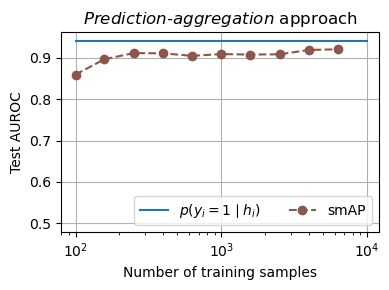

In [7]:
# Number of training samples comparison: Instance vs Embedding approaches
N_trains = [100, 158, 251, 398, 630, 1000, 1584, 2511, 3981, 6309, 10000]
bayes_aurocs = [0.9401487112045288, 0.9401487112045288, 0.9401487112045288, 0.9401487112045288, 0.9401487112045288, 0.9401487112045288, 0.9401487112045288, 0.9401487112045288, 0.9401487112045288, 0.9401487112045288, 0.9401487112045288]

# Instance approach data
instance_smap_aurocs = [0.859850, 0.897046, 0.911858, 0.911241, 0.905228, 0.909461, 0.908273, 0.908889, 0.919379, 0.921080]

# Embedding approach data
#embedding_smap_aurocs = [0.825767, 0.886403, 0.885079, 0.891080, 0.894557, 0.909737, 0.910661, 0.913466, 0.916263, 0.916715, 0.915010]

ncols, nrows = 1, 1
fig, ax = plt.subplots(figsize=(4*ncols, 3*nrows), ncols=ncols, nrows=nrows, sharey=True)

# Instance approach plot
ax.plot(N_trains, bayes_aurocs, color="#1F77B4", label=r"$p(y_i=1 \mid h_i)$")
ax.plot(N_trains[:-1], instance_smap_aurocs, color="#8C564B", label="smAP", linestyle="--", marker="o")
ax.plot([100], [0.5], color="#FFFFFF")
ax.set_title(r"$\it{Prediction}$-$\it{aggregation}$ approach")
ax.set_xlabel("Number of training samples")
ax.set_ylabel("Test AUROC")
ax.set_xscale("log")
ax.set_xlim(80, 12000)
ax.legend(loc="lower right", ncols=2)
ax.grid()

fig.tight_layout()
plt.show()

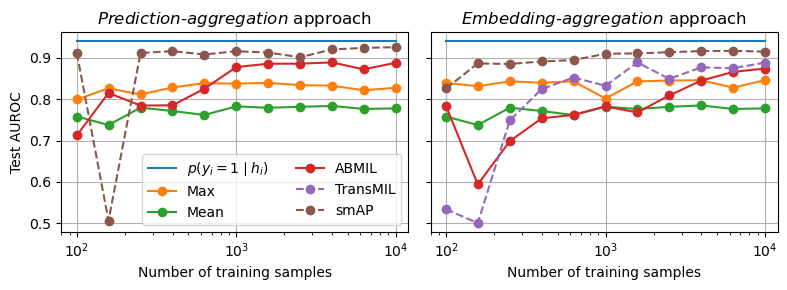

In [8]:
# Number of training samples comparison: Instance vs Embedding approaches
N_trains = [100, 158, 251, 398, 630, 1000, 1584, 2511, 3981, 6309, 10000]
bayes_aurocs = [0.9396085739135742, 0.9396085739135742, 0.9396085739135742, 0.9396085739135742, 0.9396085739135742, 0.9396085739135742, 0.9396085739135742, 0.9396085739135742, 0.9396085739135742, 0.9396085739135742, 0.9396085739135742]

# Instance approach data
instance_max_aurocs = [0.79922861, 0.82617551, 0.81138778, 0.82818407, 0.83871472, 0.8374024, 0.83935493, 0.8339535, 0.83258915, 0.82142228, 0.82751989]
instance_mean_aurocs = [0.75799811, 0.73751485, 0.77952754, 0.77141953, 0.76173103, 0.78252029, 0.77914345, 0.78147614, 0.78352463, 0.7763468, 0.77771914]
instance_attention_aurocs = [0.71253049, 0.8149966, 0.78454089, 0.78508896, 0.82515526, 0.8774966, 0.88565868, 0.88576275, 0.88885957, 0.87204719, 0.88799542]
instance_aurocs = [0.54418731, 0.49448657, 0.60938799, 0.90453953, 0.89152825, 0.92568898, 0.92719746, 0.92076778, 0.93211067, 0.93202257, 0.93477529]
instance_smap_aurocs = [0.911241, 0.506472, 0.911557, 0.916131, 0.907932, 0.915906, 0.912798, 0.901223, 0.920220, 0.923949, 0.925693]

# Embedding approach data
embedding_max_aurocs = [0.83920681, 0.83130884, 0.8430478, 0.83972704, 0.84314382, 0.80154121, 0.84288782, 0.84505439, 0.84580052, 0.82786, 0.84583652]
embedding_mean_aurocs = [0.75799805, 0.73737478, 0.77939558, 0.77136952, 0.76157498, 0.78188413, 0.77605063, 0.78147614, 0.78476489, 0.77635074, 0.77766311]
embedding_attention_aurocs = [0.78364861, 0.59374005, 0.69853681, 0.75359094, 0.76203912, 0.78248435, 0.76786065, 0.8089931, 0.84469223, 0.86586171, 0.87401581]
embedding_transformer_aurocs = [0.53374463, 0.50044215, 0.74862361, 0.82435507, 0.85234016, 0.83231711, 0.88865548, 0.84906542, 0.87685645, 0.87486798, 0.8882314]
embedding_smap_aurocs = [0.825767, 0.886403, 0.885079, 0.891080, 0.894557, 0.909737, 0.910661, 0.913466, 0.916263, 0.916715, 0.915010]

ncols, nrows = 2, 1
fig, axs = plt.subplots(figsize=(4*ncols, 3*nrows), ncols=ncols, nrows=nrows, sharey=True)

# Instance approach plot
axs[0].plot(N_trains, bayes_aurocs, color="#1F77B4", label=r"$p(y_i=1 \mid h_i)$")
axs[0].plot(N_trains, instance_max_aurocs, color="#FF7F0E", label="Max", marker="o")
axs[0].plot(N_trains, instance_mean_aurocs, color="#2CA02C", label="Mean", marker="o")
axs[0].plot(N_trains, instance_attention_aurocs, color="#D62728", label="ABMIL", marker="o")
axs[0].plot([], [], color="#9467BD", label="TransMIL", linestyle="--", marker="o")
axs[0].plot(N_trains, instance_smap_aurocs, color="#8C564B", label="smAP", linestyle="--", marker="o")
axs[0].set_title(r"$\it{Prediction}$-$\it{aggregation}$ approach")
axs[0].set_xlabel("Number of training samples")
axs[0].set_ylabel("Test AUROC")
axs[0].set_xscale("log")
axs[0].set_xlim(80, 12000)
axs[0].legend(loc="lower right", ncols=2)
axs[0].grid()

# Embedding approach plot
axs[1].plot(N_trains, bayes_aurocs, color="#1F77B4")
axs[1].plot(N_trains, embedding_max_aurocs, color="#FF7F0E", marker="o")
axs[1].plot(N_trains, embedding_mean_aurocs, color="#2CA02C", marker="o")
axs[1].plot(N_trains, embedding_attention_aurocs, color="#D62728", marker="o")
axs[1].plot(N_trains, embedding_transformer_aurocs, color="#9467BD", linestyle="--", marker="o")
axs[1].plot(N_trains, embedding_smap_aurocs, color="#8C564B", linestyle="--", marker="o")

axs[1].set_title(r"$\it{Embedding}$-$\it{aggregation}$ approach")
axs[1].set_xlabel("Number of training samples")
axs[1].set_xscale("log")
axs[1].set_xlim(80, 12000)
# Remove legend from right plot
axs[1].grid()

fig.tight_layout()
fig.savefig("varying_training_set_size.pdf", bbox_inches="tight")
plt.show()

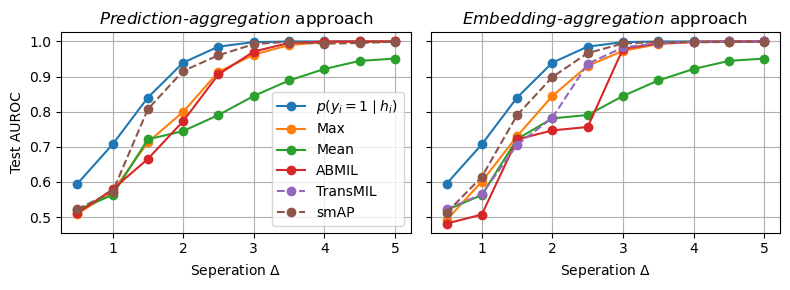

In [6]:
deltas = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]

instance_bayes_aurocs = [0.5946202278137207, 0.7070890069007874, 0.8402831554412842, 0.9396085739135742, 0.9853242635726929, 0.9980275630950928, 0.9998959302902222, 0.9999998807907104, 0.9999999403953552, 0.9999999403953552]
instance_max_aurocs = [0.50939441, 0.5724225 , 0.71332663, 0.79945076, 0.91336578, 0.96227837, 0.98967338, 0.99791551, 0.9982276 , 0.99998796]
instance_mean_aurocs = [0.51986909, 0.56306016, 0.72127265, 0.74496269, 0.79056633, 0.84471428, 0.88895154, 0.92152393, 0.9445619 , 0.95127153]
instance_attention_aurocs = [0.51072675, 0.57890421, 0.66549838, 0.77291787, 0.90620798, 0.97115672, 0.99573481, 0.99939978, 0.99997991, 0.99999988]
instance_smap_aurocs = [0.522361695766449, 0.5719543695449829, 0.8073667287826538, 0.9158865213394164, 0.9606379270553588, 0.9923421144485474, 0.9994077682495116, 0.9937903881072998, 0.9955028295516968, 0.9992838501930236]

embedding_bayes_aurocs = [0.5946202278137207, 0.7070890069007874, 0.8402831554412842, 0.9396085739135742, 0.9853242635726929, 0.9980275630950928, 0.9998959302902222, 0.9999998807907104, 0.9999999403953552, 0.9999999403953552]
embedding_max_aurocs = [0.49145383, 0.60111392, 0.73047101, 0.84476829, 0.93063831, 0.97298902, 0.99260211, 0.99847162, 0.99980396, 0.99997592]
embedding_mean_aurocs = [0.51998907, 0.56290013, 0.72213286, 0.78105593, 0.79056633, 0.84471625, 0.88895154, 0.92155594, 0.9445619 , 0.95127147]
embedding_attention_aurocs = [0.48145124, 0.50732589, 0.72098058, 0.74676311, 0.7564857, 0.97901058, 0.99417847, 0.99879968, 0.99997592, 0.99999994]
embedding_transformer_aurocs = [0.52236974, 0.56498867, 0.70559061, 0.78284842, 0.93642163, 0.98287159, 0.9947046 , 0.99934787, 0.99987584, 0.99999994]
embedding_smap_aurocs = [0.5123371481895447, 0.6145613193511963, 0.7902123332023621, 0.898664116859436, 0.9668875336647034, 0.9941824674606324, 0.998479664325714, 0.9975714087486268, 0.9985036849975586, 0.9994878768920898]

ncols, nrows = 2, 1
fig, axs = plt.subplots(figsize=(4*ncols, 3*nrows), ncols=ncols, nrows=nrows, sharey=True)

axs[0].plot([0.5], [0.5], color="#FFFFFF")
axs[0].plot(deltas, instance_bayes_aurocs, color="#1F77B4", label=r"$p(y_i=1 \mid h_i)$", marker="o")
axs[0].plot(deltas, instance_max_aurocs, color="#FF7F0E", label="Max", marker="o")
axs[0].plot(deltas, instance_mean_aurocs, color="#2CA02C", label="Mean", marker="o")
axs[0].plot(deltas, instance_attention_aurocs, color="#D62728", label="ABMIL", marker="o")
axs[0].plot([], [], color="#9467BD", label="TransMIL", linestyle="--", marker="o")
axs[0].plot(deltas, instance_smap_aurocs, color="#8C564B", label="smAP", linestyle="--", marker="o")

axs[0].set_title(r"$\it{Prediction}$-$\it{aggregation}$ approach")
axs[0].set_xlabel(r"Seperation $\Delta$")
axs[0].set_ylabel("Test AUROC")
axs[0].legend(loc="lower right")
axs[0].grid()

axs[1].plot(deltas, embedding_bayes_aurocs, color="#1F77B4", label=r"$p(y_i=1 \mid h_i)$", marker="o")
axs[1].plot(deltas, embedding_max_aurocs, color="#FF7F0E", label="Max", marker="o")
axs[1].plot(deltas, embedding_mean_aurocs, color="#2CA02C", label="Mean", marker="o")
axs[1].plot(deltas, embedding_attention_aurocs, color="#D62728", label="ABMIL", marker="o")
axs[1].plot(deltas, embedding_transformer_aurocs, color="#9467BD", label="TransMIL", linestyle="--", marker="o")
axs[1].plot(deltas, embedding_smap_aurocs, color="#8C564B", label="smAP", linestyle="--", marker="o")

axs[1].set_title(r"$\it{Embedding}$-$\it{aggregation}$ approach")
axs[1].set_xlabel(r"Seperation $\Delta$")
#axs[1].legend(loc="lower right")
axs[1].grid()

fig.tight_layout()
fig.savefig("varying_separation.pdf", bbox_inches="tight")
plt.show()

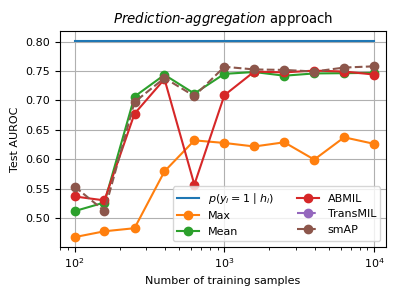

In [6]:
# Number of training samples comparison: Instance vs Embedding approaches
N_trains = [100, 158, 251, 398, 630, 1000, 1584, 2511, 3981, 6309, 10000]
bayes_aurocs = [0.8006249666213989, 0.8006249666213989, 0.8006249666213989, 0.8006249666213989, 0.8006249666213989, 0.8006249666213989, 0.8006249666213989, 0.8006249666213989, 0.8006249666213989, 0.8006249666213989, 0.8006249666213989]

# Instance approach data
instance_max_aurocs = [0.4677837491035461, 0.4776943325996399, 0.4829356372356415, 0.5794643759727478, 0.6321178674697876, 0.6276847124099731, 0.6217111349105835, 0.6288169622421265, 0.599441409111023, 0.637269139289856, 0.6261683106422424]
instance_mean_aurocs = [0.5119630694389343, 0.5265707969665527, 0.7065068483352661, 0.7433943152427673, 0.7115781307220459, 0.7450727224349976, 0.7481635212898254, 0.7419298887252808, 0.7457669377326965, 0.746211051940918, 0.7467551231384277]
instance_attention_aurocs = [0.5368334054946899, 0.530153751373291, 0.6773054599761963, 0.7361525297164917, 0.5569846034049988, 0.7087774276733398, 0.7489477396011353, 0.7475473284721375, 0.7505720853805542, 0.7490077614784241, 0.7438783645629883]
instance_smap_aurocs = [0.5535796880722046, 0.5122291445732117, 0.6971125602722168, 0.7379869222640991, 0.7073650360107422, 0.7570938467979431, 0.7525327205657959, 0.7517445087432861, 0.7489997744560242, 0.7557534575462341, 0.7578580379486084]

ncols, nrows = 1, 1
fig, ax = plt.subplots(figsize=(4*ncols, 3*nrows), ncols=ncols, nrows=nrows, sharey=True)

# Instance approach plot
ax.plot(N_trains, bayes_aurocs, color="#1F77B4", label=r"$p(y_i=1 \mid h_i)$")
ax.plot(N_trains, instance_max_aurocs, color="#FF7F0E", label="Max", marker="o")
ax.plot(N_trains, instance_mean_aurocs, color="#2CA02C", label="Mean", marker="o")
ax.plot(N_trains, instance_attention_aurocs, color="#D62728", label="ABMIL", marker="o")
ax.plot([], [], color="#9467BD", label="TransMIL", linestyle="--", marker="o")
ax.plot(N_trains, instance_smap_aurocs, color="#8C564B", label="smAP", linestyle="--", marker="o")
ax.set_title(r"$\it{Prediction}$-$\it{aggregation}$ approach")
ax.set_xlabel("Number of training samples")
ax.set_ylabel("Test AUROC")
ax.set_xscale("log")
ax.set_xlim(80, 12000)
ax.legend(loc="lower right", ncols=2)
ax.grid()

fig.tight_layout()
fig.savefig("varying_training_set_size.pdf", bbox_inches="tight")
plt.show()